# Bohr Sommerfeld Qunatisierung

[Tangent half ange substitution](https://en.wikipedia.org/wiki/Tangent_half-angle_substitution)

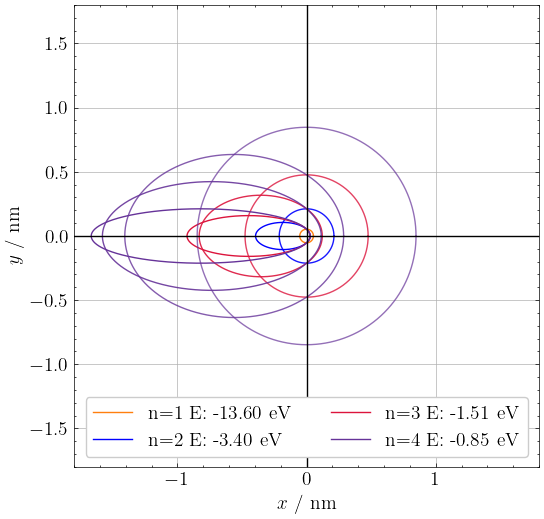

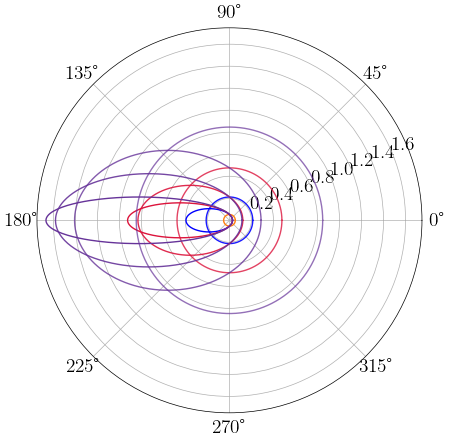

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, elementary_charge, electron_mass, proton_mass, epsilon_0
import scienceplots
plt.style.use('science')
plt.rcParams.update({'font.size': 14})

M = 1*proton_mass
m = 1*electron_mass
e = elementary_charge / np.sqrt(4 * np.pi * epsilon_0)
mu = M*m / (M + m)

phi = np.linspace(0,2*np.pi,1000)

ns = [1,2,3,4]
color = ['tab:orange', 'blue', 'crimson', 'rebeccapurple']
alp = {1:1, 2:0.9, 3:0.8, 4:0.7}


# _eps = lambda E, p_phi : np.sqrt(1+ 2*E / (mu*e**4) * p_phi**2)

_eps2 = lambda n, n_phi : np.sqrt(1-(n_phi/n)**2)

fig1, ax1 = plt.subplots(1,1, figsize=(6,6))
ax1.grid()
ax1.set_xlabel(r'$x$ / nm')
ax1.set_ylabel(r'$y$ / nm')
ax1.set_xlim(-1.8,1.8)
ax1.set_ylim(-1.8,1.8)

fig2 = plt.figure(figsize=(6,5))
ax2 = fig2.add_subplot(111, polar=True)

for n in ns:
    E = -mu*e**4 / (2*hbar**2) / n**2
    c = color[n-1]

    for n_phi in range(1,n+1):
        p_phi = n_phi * hbar
        p = p_phi**2 / (mu*e**2)

        eps = _eps2(n, n_phi)
        a = hbar**2 / (mu*e**2) * n**2
        b = a * n_phi / n

        a *= 1e9
        b *= 1e9

        r = lambda phi: p/(1+eps*np.cos(phi)) * 1e9

        alpha = alp[n_phi]
        if n_phi == 1:
            ax1.plot(
                -a*eps + a*np.cos(phi), 
                b*np.sin(phi), 
                color=c, 
                alpha=alpha, 
                label=f'n={n} E: {E/elementary_charge:.2f} eV'
            )
            ax2.plot(phi, r(phi), color=c, alpha=alpha,
                label=f'n:{n} E: {E/elementary_charge:.2f} eV')
        else:
            ax1.plot(-a*eps + a*np.cos(phi), 
                b*np.sin(phi), color=c, alpha=alpha)
            ax2.plot(phi, r(phi), color=c, alpha=alpha)

ax1.legend(frameon=True, ncols=2, loc='lower center', framealpha=1)
ax1.axhline(y=0, color='k')
ax1.axvline(x=0, color='k')

plt.show()